In [ ]:
import pandas as pd
import numpy as np 
import plotly.express as px
import seaborn as sns

In [2]:
df = pd.read_csv('Students Social Media Addiction.csv')

In [3]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [4]:
df.shape 

(705, 13)

In [5]:
df.dtypes

Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

In [6]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

In [7]:
df['Student_ID'].duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
700    False
701    False
702    False
703    False
704    False
Name: Student_ID, Length: 705, dtype: bool

In [8]:
df.rename(columns={'Student_ID':'ID_Estudante', 'Age':'Idade', 'Gender':'Gênero', 'Academic_Level':'Escolaridade',
                   'Country':'País', 'Avg_Daily_Usage_Hours':'Média_Horas_de_Uso', 'Most_Used_Platform':'Plataforma_Mais_Usada',
                   'Affects_Academic_Performance':'Efeitos_na_Performance_Academica', 'Sleep_Hours_Per_Night':'Horas_Dormidas_Por_Noite', 'Mental_Health_Score':'Classificação_da_Saúde_Mental',
                   'Relationship_Status':'Status_Social', 'Conflicts_Over_Social_Media':'Conflitos_Através_das_Redes_Sociais', 'Addicted_Score':'Taxa_Dependencia'}, inplace=True)

In [9]:
df.head()

,ID_Estudante,Idade,Gênero,Escolaridade,País,Média_Horas_de_Uso,Plataforma_Mais_Usada,Efeitos_na_Performance_Academica,Horas_Dormidas_Por_Noite,Classificação_da_Saúde_Mental,Status_Social,Conflitos_Através_das_Redes_Sociais,Taxa_Dependencia
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [10]:
categoria = {'Yes':1, 'No':0}
status_social = {'Single':1, 'In Relationship':2, 'Complicated':3}

In [11]:
df['Efeitos_na_Performance_Academica Bolean'] = df['Efeitos_na_Performance_Academica'].map(categoria)

In [12]:
df['Status_Social Ordenado'] = df['Status_Social'].map(status_social)

In [13]:
# Ordenando as variáveis 

organizando_variáveis = ['ID_Estudante', 'Idade', 'Gênero', 'Escolaridade', 'País', 'Média_Horas_de_Uso', 
                         'Plataforma_Mais_Usada', 'Efeitos_na_Performance_Academica', 'Efeitos_na_Performance_Academica Bolean', 'Horas_Dormidas_Por_Noite',
                         'Classificação_da_Saúde_Mental', 'Status_Social', 'Status_Social Ordenado','Conflitos_Através_das_Redes_Sociais', 'Taxa_Dependencia']

df = df[organizando_variáveis]

In [14]:
df.head()

,ID_Estudante,Idade,Gênero,Escolaridade,País,Média_Horas_de_Uso,Plataforma_Mais_Usada,Efeitos_na_Performance_Academica,Efeitos_na_Performance_Academica Bolean,Horas_Dormidas_Por_Noite,Classificação_da_Saúde_Mental,Status_Social,Status_Social Ordenado,Conflitos_Através_das_Redes_Sociais,Taxa_Dependencia
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,1,6.5,6,In Relationship,2,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,0,7.5,8,Single,1,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,1,5.0,5,Complicated,3,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,0,7.0,7,Single,1,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,1,6.0,6,In Relationship,2,2,7


In [15]:
Q1 = np.quantile(df['Idade'], 0.25)

In [16]:
Q2 = np.quantile(df['Idade'], 0.50)

In [17]:
Q3 = np.quantile(df['Idade'], 0.75)

In [45]:
IQR = Q3 - Q1

In [47]:
print(IQR)

3.0


In [19]:
# Coeficiente de Gilbert Bowley

gb = ((Q3 - Q2) - (Q2 - Q1) / (Q3 - Q1))

In [49]:
print(round(gb, 2))

0.33


In [20]:
gb.round(2)

np.float64(0.33)

In [21]:
round(df['Idade'].std(), 2)

1.4

<Axes: xlabel='Idade', ylabel='Gênero'>

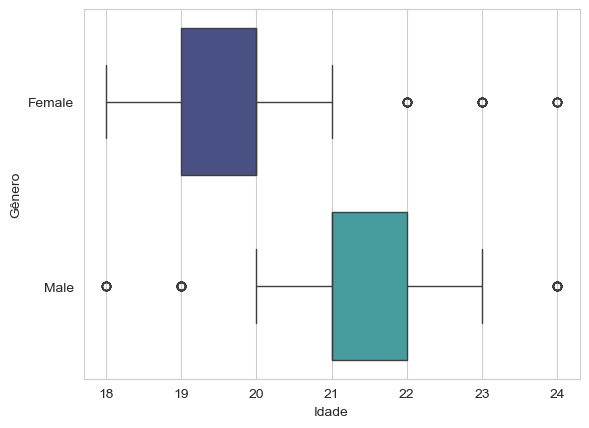

In [22]:
sns.boxplot(df, x=df['Idade'], y=df['Gênero'], hue=df['Gênero'], palette='mako')

<Axes: xlabel='Idade'>

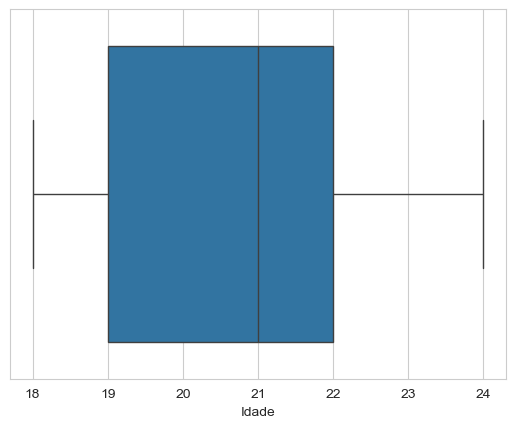

In [23]:
sns.boxplot(df, x='Idade')

<Axes: xlabel='Idade', ylabel='Count'>

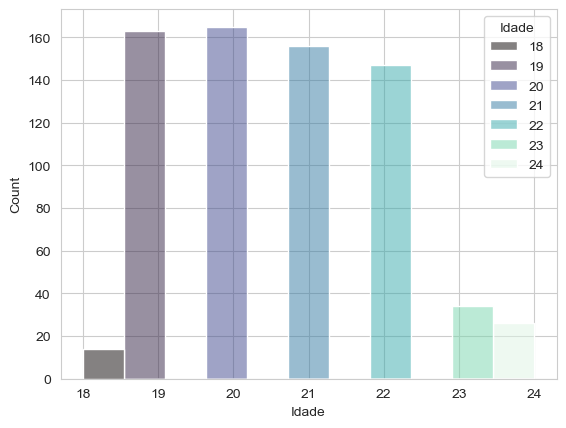

In [44]:
sns.histplot(df, x=df['Idade'], hue=df['Idade'], palette="mako", shrink=1)

<Axes: xlabel='Idade', ylabel='Escolaridade'>

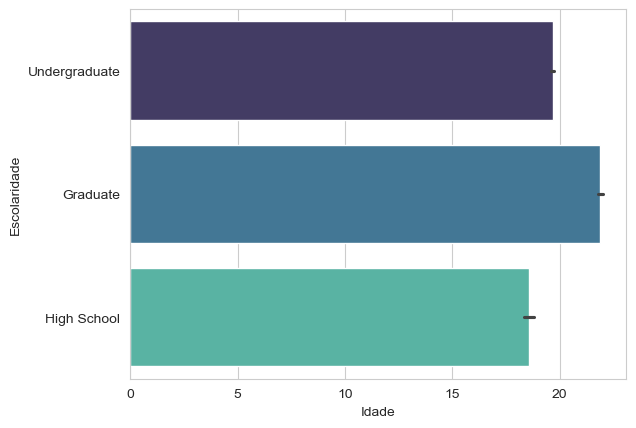

In [25]:
sns.barplot(df, x=df['Idade'], y=df['Escolaridade'], hue=df['Escolaridade'], palette='mako')

<Axes: xlabel='ID_Estudante', ylabel='Escolaridade'>

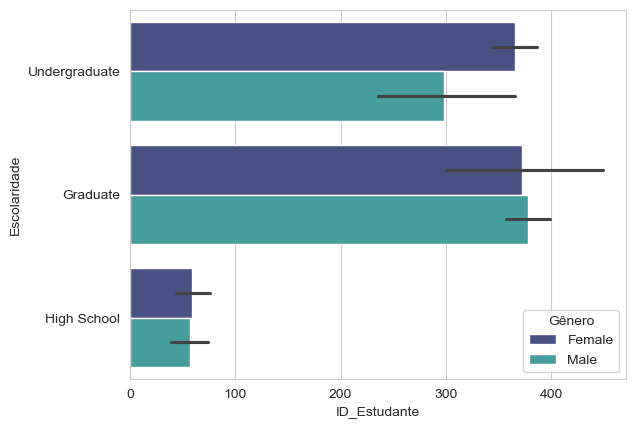

In [26]:
sns.barplot(df, x=df['ID_Estudante'], y=df['Escolaridade'], hue=df['Gênero'], palette='mako')

In [27]:
Q1

np.float64(19.0)

In [28]:
M1 = len(df.loc[(df['Idade'] >= 18) & (df['Idade'] <= 19) & (df['Gênero'] == 'Male')])

In [29]:
M2 = len(df.loc[(df['Idade'] >= 20) & (df['Idade'] <= 21) & (df['Gênero'] == 'Male')])

In [30]:
M3 = len(df.loc[(df['Idade'] >= 22) & (df['Idade'] <= 23) & (df['Gênero'] == 'Male')])

In [31]:
M4 = len(df.loc[(df['Idade'] >= 24) & (df['Gênero'] == 'Male')])

In [32]:
M4

18

In [33]:
M1, M2, M3, M4

(37, 144, 153, 18)

In [34]:
F1 = len(df.loc[(df['Idade'] >= 18) & (df['Idade'] <= 19) & (df['Gênero'] == 'Female')])

In [35]:
F2 = len(df.loc[(df['Idade'] >= 20) & (df['Idade'] <= 21) & (df['Gênero'] == 'Female')])

In [36]:
F3 = len(df.loc[(df['Idade'] >= 22) & (df['Idade'] <= 23) & (df['Gênero'] == 'Female')])

In [37]:
F4 = len(df.loc[(df['Idade'] >= 24) & (df['Gênero'] == 'Female')])

In [38]:
F1, F2, F3, F4

(140, 177, 28, 8)

In [39]:
len(df.loc[(df['Gênero'] == "Female")])

353

In [40]:
df.shape

(705, 15)